# Exploratory Data Analysis: Spatial Organization of PC weights

In [1]:
% load data
addpath('matlab','data')
load('calcium_data.mat')
load('stimuli_info.mat')
load ('data_stimsorted.mat')
load('ROI_positions.mat')

In [2]:
%Variables
thrld = 0.25;
fov = 1; % 1 of 8 FOV
tbin = 0.5; % 1 second time bin
num_rois = numel(fieldnames(dat_sorted{fov}.deNoise_dff));
stimulus = {'e3', 'e2', 'e1', 'd3', 'd2', 'd1', 'c3', 'c2', 'c1', 'blank'};
stim_onset = 5;

## 1. Random Shuffle

Shuffle Population Array across ROIS and run PCA.

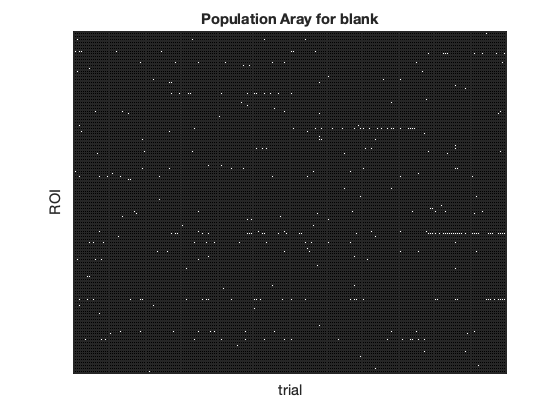

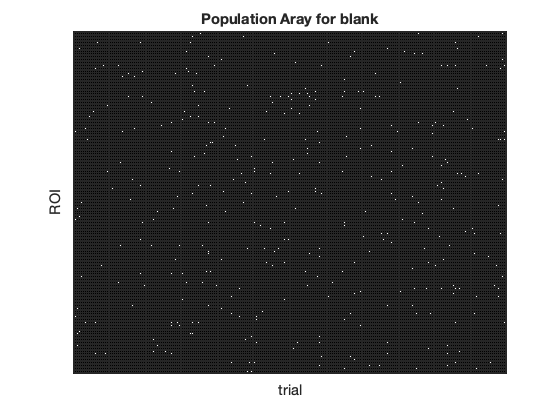

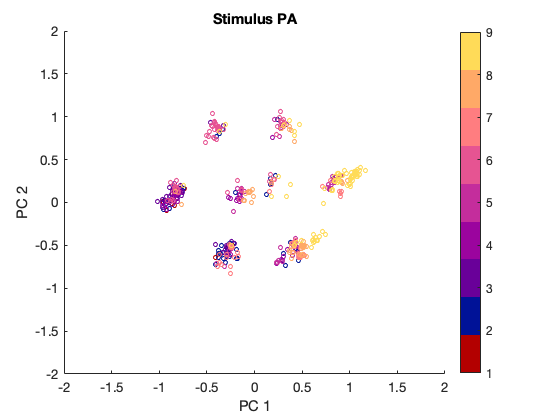

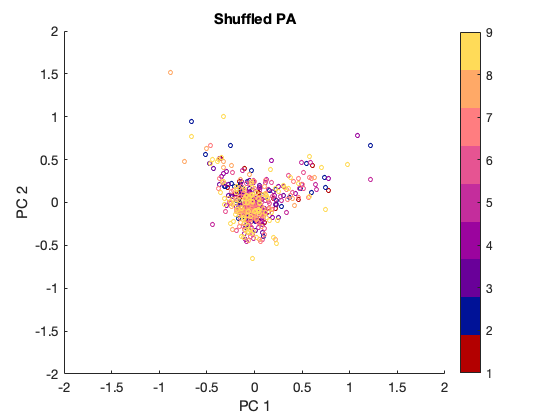

In [14]:
% Random Shuffle across ROIs
[stim_PA, stim_label] = get_stim_PA(dat_sorted,fov,thrld,stim_onset,tbin);
shuffled_PA = shuffle_PA(stim_PA,2);

%Verify by Looking at Population Array
figure(1)
plot_poparray(stim_PA(1:223,:).', 10)
figure(2)
plot_poparray(shuffled_PA(1:223,:).',10)

%Run PCA on both Arrays
[PCA_allstim.coeff,PCA_allstim.score,PCA_allstim.latent] = pca(stim_PA, 'Centered', true);
figure(3)
plot_PCA(PCA_allstim.score, stim_label, 'Stimulus PA')

[PCA_shuffled.coeff,PCA_shuffled.score,PCA_shuffled.latent] = pca(shuffled_PA, 'Centered', true);
figure(4)
plot_PCA(PCA_shuffled.score, stim_label, 'Shuffled PA')

## 2. Check the Cluster Composition: what proportion of stimulus trials are in each cluster 

Compare the histograms for regular PCA and unweighted PCA

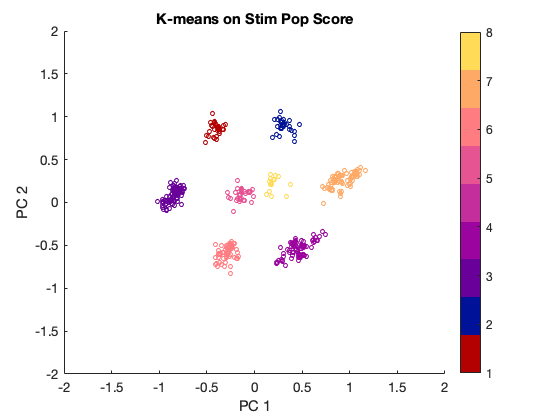

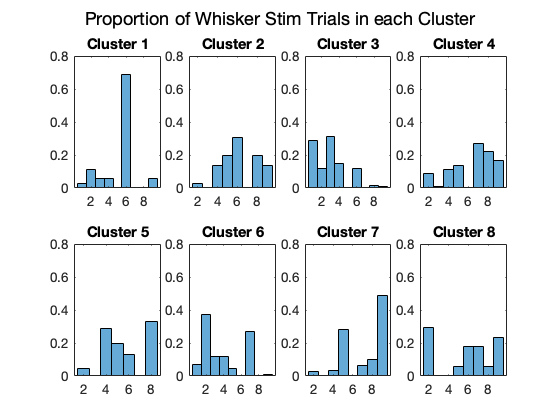

In [42]:
%K-means on PC Data
cluster_num = 8;
[cluster_lbls,centroid_locs,sumd] = kmeans(PCA_allstim.score(:,1:2),cluster_num, 'Distance', 'sqeuclidean');
figure(1)
plot_PCA(PCA_allstim.score, cluster_lbls, 'K-means on Stim Pop Score')

% Proportion of all whisker stim trials contained in each cluster
figure(2)
for cluster = 1:8
    idx = find(cluster_lbls == cluster); % find index position of cluster
    cluster_stim = stim_label(idx); % retrieve which whisker was deflected in that trial 
    subplot(2,4,cluster)
    histogram(cluster_stim, 'Normalization', 'probability') % plot histogram 
    ylim([0,0.8])
    plt_title = ['Cluster ',num2str(cluster)];
    title(plt_title)
end
sgtitle('Proportion of Whisker Stim Trials in each Cluster')

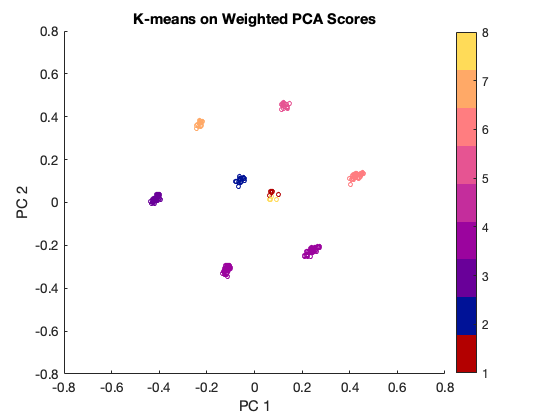

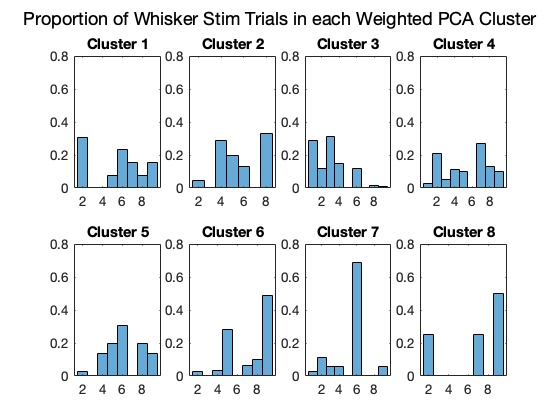

In [111]:
%weighted PCA 
wt1 = var(stim_PA);
wt1(wt1==0) = 0.001; % make zero really small 
[wcoeff,wscore,wlatent] = pca(stim_PA, 'Centered', true, 'VariableWeights', wt1);

% K-means on Weighted PCA Scores 
cluster_num = 8;
[cluster_lbls_weighted,centroid_locs_weighted,sumd_weighted] = kmeans(wscore(:,1:2),cluster_num, 'Distance', 'cityblock');
figure(1)
plot_PCA(wscore, cluster_lbls_weighted, 'K-means on Weighted PCA Scores')
xlim([-0.8,0.8])
ylim([-0.8,0.8])

% Proportion of each whisker stimulus contained in each cluster
figure(2)
for cluster = 1:8
    idx = find(cluster_lbls_weighted == cluster); % find index position of cluster
    cluster_stim = stim_label(idx); % retrieve which whisker was deflected in that trial 
    subplot(2,4,cluster)
    histogram(cluster_stim, 'Normalization', 'probability') % plot histogram 
    ylim([0,0.8])
    plt_title = ['Cluster ',num2str(cluster)];
    title(plt_title)
end
sgtitle('Proportion of Whisker Stim Trials in each Weighted PCA Cluster')

The cluster in wPCA vs PCA are the same, but they're better localized in wPCA.

## 3. Looks at clusters on spatial map of ROIs
1. identify the trials belonging to each cluster
2. Take average dF/F for those trials 
3. Plot on spatial map of ROIs

In [1]:
cluster_info

Error using eval
Undefined function or variable 'cluster_info'.



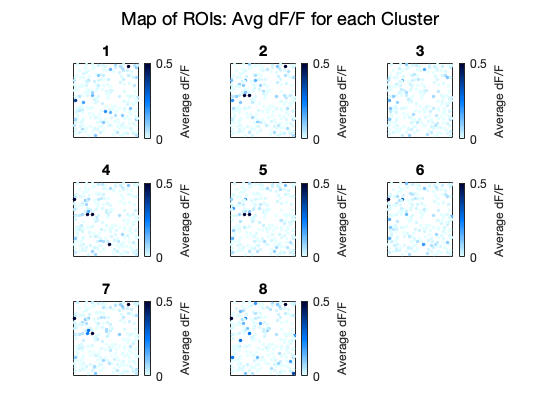

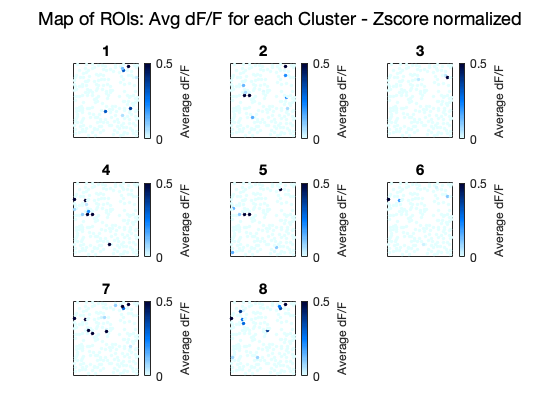

In [121]:
% Get dFF for all trials within cluster 
cluster_info = cluster_idxs(dat_sorted,fov, cluster_lbls, stim_label);
[cluster_info,cluster_dff_avg, cluster_dff_avg_norm] = get_dff_cluster(data, dat_sorted, fov, cluster_info, tbin);     

% Get ROI Positions 
x_pst = zeros(numel(fields(ROI_position{fov}.ROI_centroids)),1);
y_pst = zeros('like',x_pst);
for i = 1:numel(fields(ROI_position{fov}.ROI_centroids))
    roi = ['ROI', num2str(i)];
    x_pst(i) = ROI_position{fov}.ROI_centroids.(roi)(1);
    y_pst(i) = ROI_position{fov}.ROI_centroids.(roi)(2);
end

%Plot average dF/F on map of ROIs
figure(1)
for clust = 1:length(cluster_info)
    subplot(3,3,clust)
    plot_clusteronROIS(x_pst, y_pst, cluster_dff_avg(:,clust), [num2str(clust)],8)
%     caxis([0,0.25])
end
sgtitle('Map of ROIs: Avg dF/F for each Cluster')

% Z-score dF/F
figure(2)
for clust = 1:length(cluster_info)
    subplot(3,3,clust)
    plot_clusteronROIS(x_pst, y_pst, cluster_dff_avg_norm(:,clust), [num2str(clust)],8)
%     caxis([0,0.25])
end
sgtitle('Map of ROIs: Avg dF/F for each Cluster - Zscore normalized')

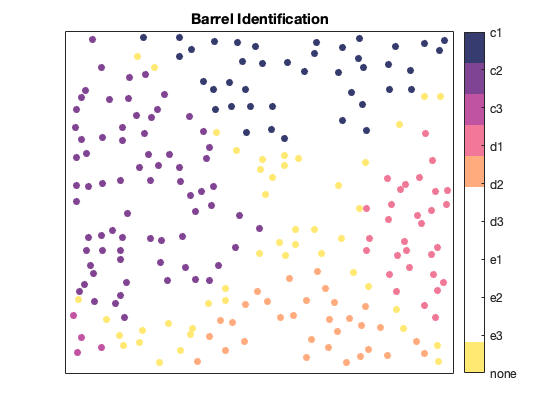

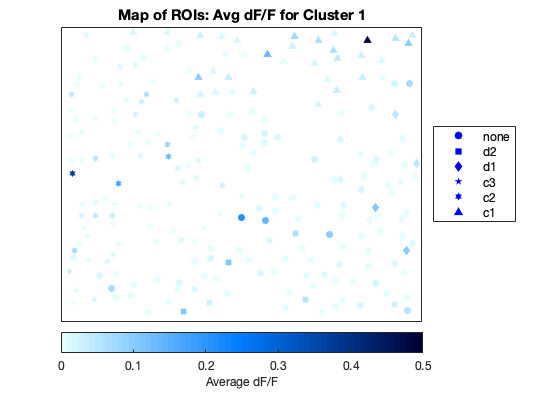

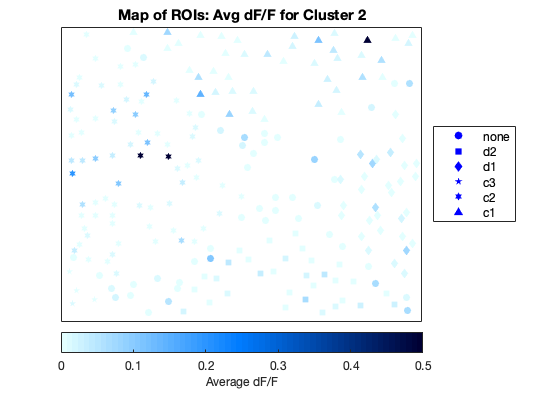

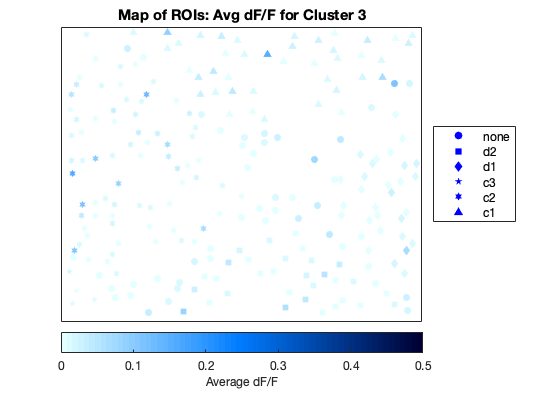

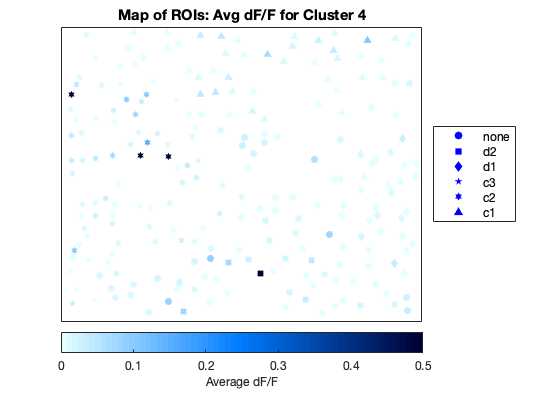

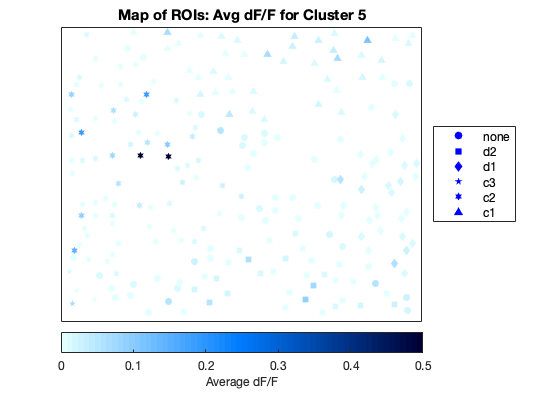

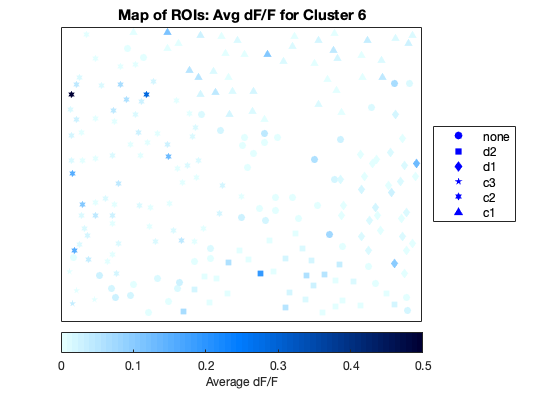

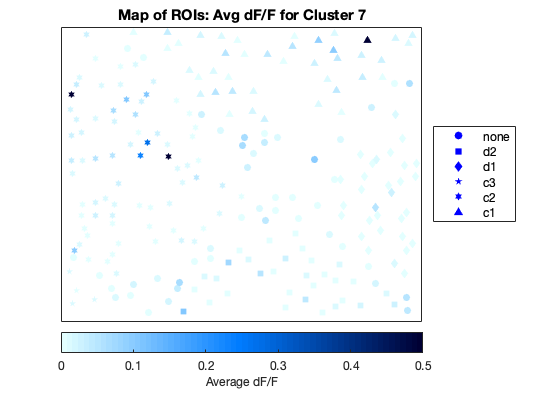

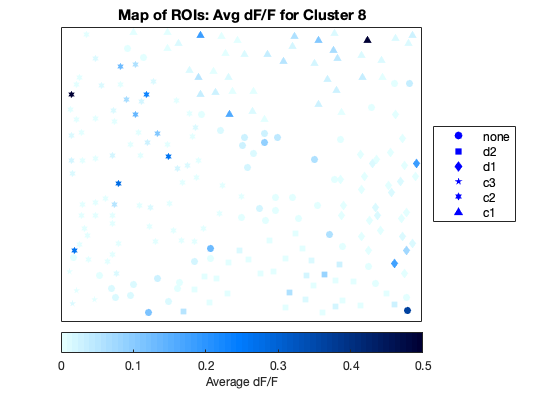

In [122]:
%Plot average dF/F on map of ROIs with barrel columns specified
column_identity = get_barrel_identity(ROI_position, fov); % get column barrel identities 
figure(1)
plot_clusteronROIS(x_pst, y_pst, column_identity,'Barrel Identification',30)
cmap_column = [0.212,0.235,0.435;
          0.502,0.267,0.580;
          0.757,0.329,0.635;
          0.945,0.471,0.596;
          1.000,0.671,0.494;
          1.000,1.000,1.000;
          1.000,1.000,1.000;
          1.000,1.000,1.000;
          1.000,1.000,1.000;
          1.000,1.000,1.000;
          1.000,0.914,0.451];
caxis('auto');
colormap(flipud(cmap_column));
bcolumns = {'none','e3', 'e2', 'e1', 'd3', 'd2', 'd1', 'c3', 'c2', 'c1'};
colorbar('TickLabels', bcolumns)

%turn off warnings
id = 'MATLAB:legend:IgnoringExtraEntries';
warning('off',id)

for clust = 1:length(cluster_info)
    figure(clust+1)
    plot_clst_barrels(x_pst, y_pst, cluster_dff_avg(:,clust), column_identity, ['Map of ROIs: Avg dF/F for Cluster ', num2str(clust)],30)
    
end


## 4. Spatial Organization of PC Weights

1. Try mapping the PC weights onto the ROI positions 
2. Try marking the top weighted ROIS for each PC on the map of ROI position 
3. Look at the spatial organization of the clusters that arise from K-means on raw population array

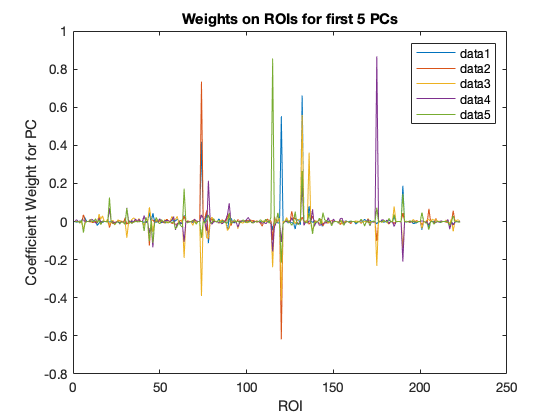

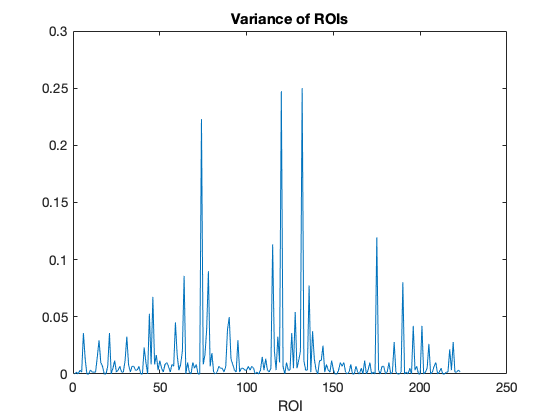

In [124]:
% 1. Plot top contirbuting ROIS to first few PCs
% Plot PC loadings
figure(1)
plot(PCA_allstim.coeff(:,1:5))
fire_ice = customcolormap_preset('red-white-blue');
colormap(fire_ice)
xlabel('ROI')
ylabel('Coefficient Weight for PC')
title('Weights on ROIs for first 5 PCs')
legend

figure(2)
plot(var(stim_PA))
title('Variance of ROIs')
xlabel('ROI')



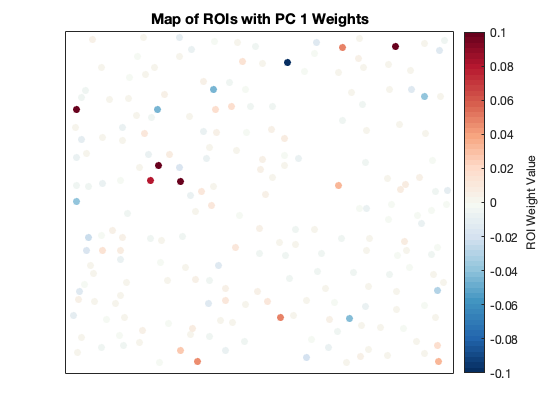

In [123]:
% 2. Map of PC weights on ROI positions

%Plot ROIs and PC Loadings 4
PC = 1;
plot_ROIlabel(x_pst, y_pst, PCA_allstim.coeff(:,PC), ['Map of ROIs with PC ', num2str(PC), ' Weights'])
% z = zscore(PCA_allstim.coeff(:,PC));
% plot(z)

The contributing ROIs for the first few PCs are few overlap greatly 

## 5. K-means on Pop Arrray - cluster ROIs 

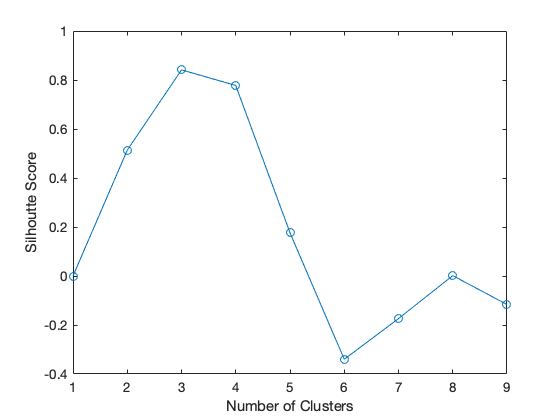

In [142]:
% Silhoutte Analysis to determine cluster number - cluster ROIs not trials 
s_score = zeros(9,1);
for cluster_num = 1:9
    cluster_lbls = kmeans(stim_PA.',cluster_num, 'Distance', 'sqeuclidean');
    s = silhouette(stim_PA.',cluster_lbls);
    s_score(cluster_num) = mean(s);
end

s_score(1) = 0;
plot(s_score, '-o')
xlabel('Number of Clusters')
%label('Silhoutte Score')

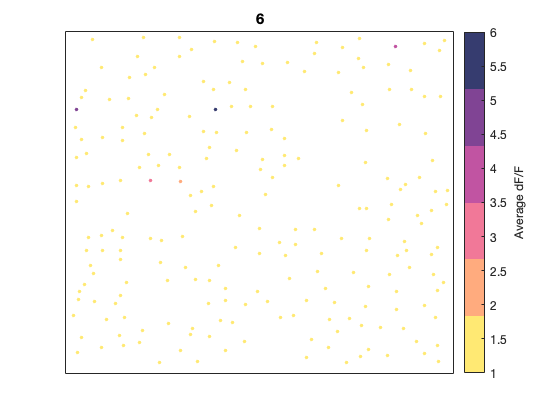

In [168]:

cluster_num = 6;
[cluster_lbls_raw,centroid_locs_raw,sumd_raw] = kmeans(stim_PA.',cluster_num, 'Distance', 'cityblock');

plot_clusteronROIS(x_pst, y_pst, cluster_lbls_raw, [num2str(cluster_num)],8)
cmap_column = [0.212,0.235,0.435;
          0.502,0.267,0.580;
          0.757,0.329,0.635;
          0.945,0.471,0.596;
          1.000,0.671,0.494;
          1.000,0.914,0.451];
caxis('auto');
colormap(flipud(cmap_column));

## 6. K-means on Pop Arrray - cluster trials 

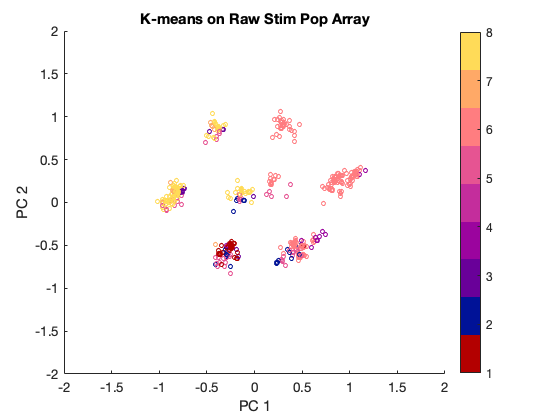

In [61]:
% K-means on Raw Data - Look for where centroids map on ROI Map 
cluster_num = 8;
[cluster_lbls_raw,centroid_locs_raw,sumd_raw] = kmeans(stim_PA,cluster_num, 'Distance', 'cityblock');
plot_PCA(PCA_allstim.score, cluster_lbls_raw, 'K-means on Raw Stim Pop Array')

% plot(centroid_locs_raw(7,:).')
% ROI_position{fov}.barrelAssignment_Barrel.(roi)
% ROI_position{1}.barrelAssignment_Barrel

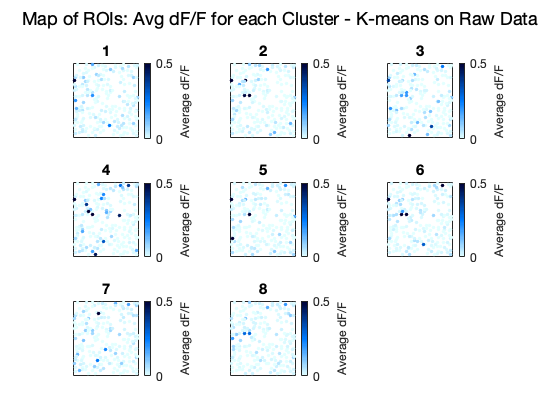

In [62]:
% K-means on Raw Data - Look for where centroids map on ROI Map 
cluster_num = 8;
[cluster_lbls_raw,centroid_locs_raw,sumd_raw] = kmeans(stim_PA,cluster_num, 'Distance', 'cityblock');

% Get dFF for all trials within cluster 
cluster_info_raw = cluster_idxs(dat_sorted,fov, cluster_lbls_raw, stim_label);
[cluster_info,cluster_dff_avg, cluster_dff_avg_norm] = get_dff_cluster(dat_sorted, fov, cluster_info_raw, tbin);     

%Plot average dF/F on map of ROIs
for clust = 1:length(cluster_info_raw)
    subplot(3,3,clust)
    plot_clusteronROIS(x_pst, y_pst, cluster_dff_avg_raw(:,clust), [num2str(clust)],8)
end
sgtitle('Map of ROIs: Avg dF/F for each Cluster - K-means on Raw Data')